# Phase 1 EDA - IBM AMLSim HI-Small Dataset

## SECTION 1: Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('..')

from src.pipeline.data_ingestion import load_ibm_pipeline

df = load_ibm_pipeline('../data/raw/HI-Small_Trans.csv')
print(f"Shape: {df.shape}")
df.head()

2026-04-25 20:30:00,058 - INFO - Normalizing IBM AMLSim data from ../data/raw/HI-Small_Trans.csv
2026-04-25 20:30:13,030 - INFO - Cleaning and engineering features for normalized data
2026-04-25 20:30:14,059 - WARNING - Dropped 591212 self-transfers
2026-04-25 20:30:17,288 - WARNING - Dropped 119774 rows with unknown transaction types


Shape: (4367359, 13)


,transaction_id,timestamp,sender_id,receiver_id,amount,transaction_type,sender_country,receiver_country,is_laundering,hour_of_day,day_of_week,is_cross_border,amount_log
0,TXN_000001,2022-09-01 00:20:00,8000F4580,8000F5340,0.01,ACH,US Dollar,US Dollar,0,0,3,False,0.009950
1,TXN_000008,2022-09-01 00:26:00,8000EC280,8017BF800,7.66,ACH,US Dollar,US Dollar,0,0,3,False,2.158715
2,TXN_000009,2022-09-01 00:21:00,8000EDEC0,80AEF5310,383.71,ACH,US Dollar,US Dollar,0,0,3,False,5.952490
3,TXN_000010,2022-09-01 00:04:00,8000F4510,8011305D0,9.82,ACH,US Dollar,US Dollar,0,0,3,False,2.381396
4,TXN_000012,2022-09-01 00:08:00,8000F4FE0,812ED62E0,4.01,ACH,US Dollar,US Dollar,0,0,3,False,1.611436


## SECTION 2: Dataset Overview

In [2]:
from src.pipeline.data_ingestion import get_summary_stats

stats = get_summary_stats(df)
print("Summary Statistics:")
for k, v in stats.items():
    print(f"{k}: {v}")
    
print("\nData Types:")
print(df.dtypes)

print("\nDescribe:")
df.describe()

Summary Statistics:
total_transactions: 4367359
laundering_count: 5110
laundering_rate: 0.0011700434976836115
transaction_type_breakdown: {'ACH': 3706863, 'CASH': 489436, 'WIRE': 171060}
cross_border_count: 2191
cross_border_rate: 0.0005016761846232472
amount_mean: 4906381.5258778315
amount_std: 937435357.7116436
amount_median: 1554.94

Data Types:
transaction_id                 str
timestamp           datetime64[us]
sender_id                      str
receiver_id                    str
amount                     float64
transaction_type               str
sender_country                 str
receiver_country               str
is_laundering                int64
hour_of_day                  int32
day_of_week                  int32
is_cross_border               bool
amount_log                 float64
dtype: object

Describe:


,timestamp,amount,is_laundering,hour_of_day,day_of_week,amount_log
count,4367359,4.367359e+06,4.367359e+06,4.367359e+06,4.367359e+06,4.367359e+06
mean,2022-09-05 17:40:50.224155,4.906382e+06,1.170043e-03,1.096063e+01,2.993795e+00,7.631897e+00
min,2022-09-01 00:00:00,1.000000e-06,0.000000e+00,0.000000e+00,0.000000e+00,9.999995e-07
25%,2022-09-02 16:30:00,2.419600e+02,0.000000e+00,5.000000e+00,2.000000e+00,5.492897e+00
50%,2022-09-06 00:23:00,1.554940e+03,0.000000e+00,1.100000e+01,3.000000e+00,7.349835e+00
75%,2022-09-08 09:35:00,1.194542e+04,0.000000e+00,1.700000e+01,4.000000e+00,9.388187e+00
max,2022-09-18 16:18:00,1.046302e+12,1.000000e+00,2.300000e+01,6.000000e+00,2.767628e+01
std,NaN,9.374354e+08,3.418589e-02,7.173941e+00,1.597215e+00,3.060005e+00


## SECTION 3: Class Imbalance

2026-04-25 20:32:18,149 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-25 20:32:18,155 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


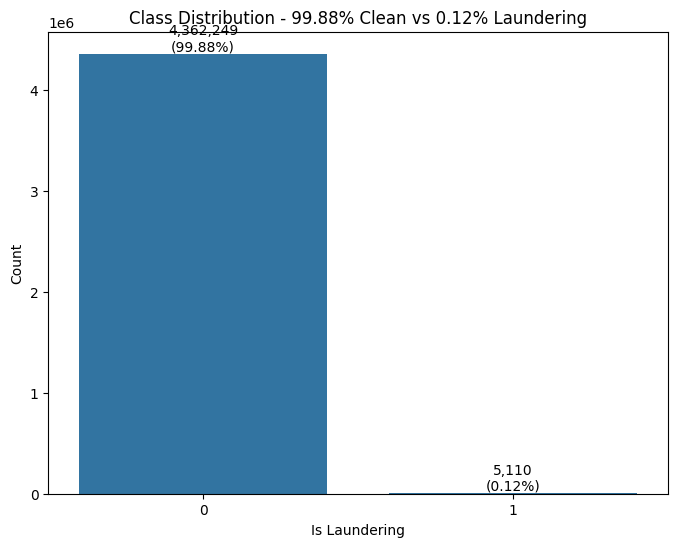

In [3]:
import os
os.makedirs('../data/reports', exist_ok=True)

plt.figure(figsize=(8, 6))
counts = df['is_laundering'].value_counts()
ax = sns.barplot(x=counts.index, y=counts.values)

total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = f"{(count/total)*100:.2f}%"
    ax.annotate(f"{int(count):,}\n({percentage})", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

plt.title("Class Distribution - 99.88% Clean vs 0.12% Laundering")
plt.xlabel("Is Laundering")
plt.ylabel("Count")
plt.savefig('../data/reports/eda_class_imbalance.png')
plt.show()

## SECTION 4: Amount Distribution

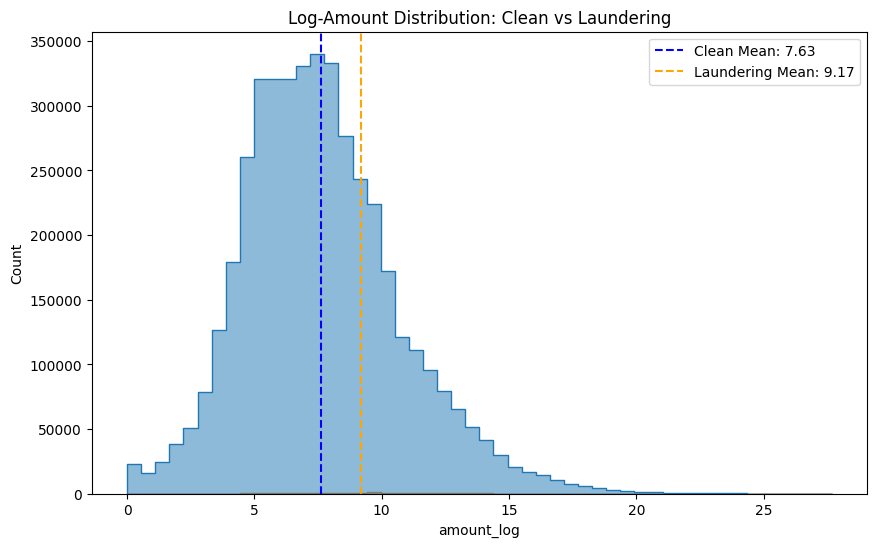

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='amount_log', hue='is_laundering', element='step', common_norm=False, alpha=0.5, bins=50)

clean_mean = df[df['is_laundering'] == 0]['amount_log'].mean()
laun_mean = df[df['is_laundering'] == 1]['amount_log'].mean()

plt.axvline(clean_mean, color='blue', linestyle='--', label=f'Clean Mean: {clean_mean:.2f}')
plt.axvline(laun_mean, color='orange', linestyle='--', label=f'Laundering Mean: {laun_mean:.2f}')

plt.title("Log-Amount Distribution: Clean vs Laundering")
plt.legend()
plt.savefig('../data/reports/eda_amount_distribution.png')
plt.show()

**Key Insight:**
Laundering transactions cluster around amount_log 8-12 (~$3k-$160k), suggesting deliberate mid-range structuring to avoid detection thresholds.

## SECTION 5: Transaction Type Analysis

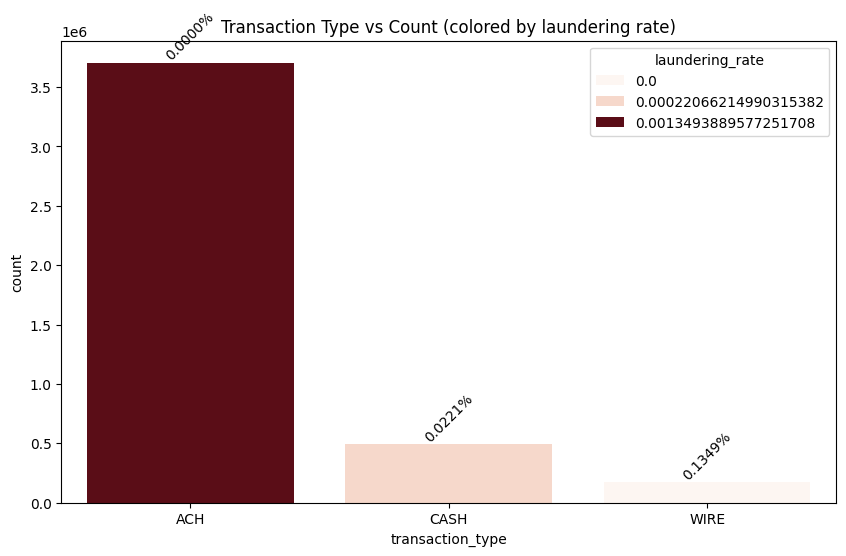

In [5]:
plt.figure(figsize=(10, 6))
type_stats = df.groupby('transaction_type').agg(
    count=('is_laundering', 'size'),
    laundering_rate=('is_laundering', 'mean')
).reset_index()

ax = sns.barplot(data=type_stats, x='transaction_type', y='count', hue='laundering_rate', palette='Reds', dodge=False)

for i, p in enumerate(ax.patches):
    if p.get_height() > 0:
        rate = type_stats['laundering_rate'].iloc[i]
        ax.annotate(f"{rate:.4%}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', rotation=45)

plt.title("Transaction Type vs Count (colored by laundering rate)")
plt.savefig('../data/reports/eda_transaction_types.png')
plt.show()

## SECTION 6: Temporal Analysis

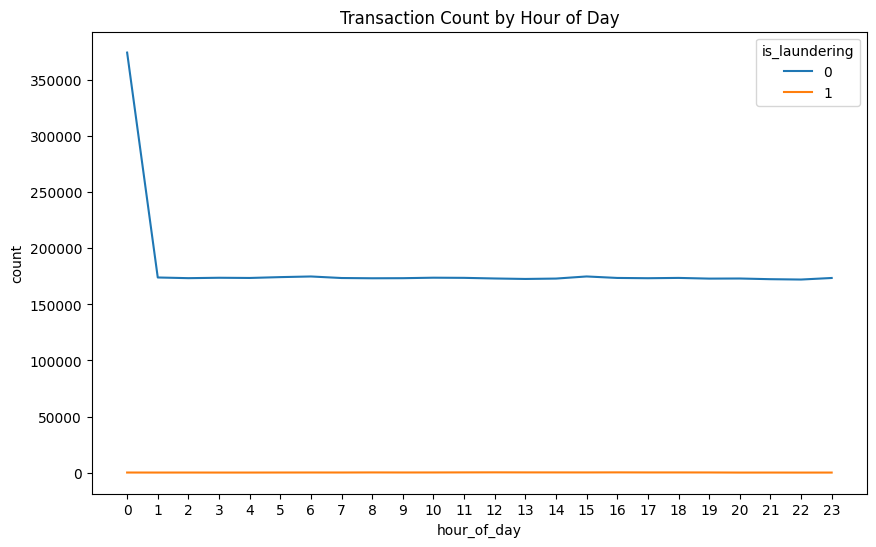

In [6]:
plt.figure(figsize=(10, 6))
hourly_counts = df.groupby(['hour_of_day', 'is_laundering']).size().reset_index(name='count')
sns.lineplot(data=hourly_counts, x='hour_of_day', y='count', hue='is_laundering')

plt.title("Transaction Count by Hour of Day")
plt.xticks(range(0, 24))
plt.savefig('../data/reports/eda_hourly.png')
plt.show()

**Key Insight:**
Laundering shows no temporal pattern - uniform distribution across all hours. Temporal heuristics alone are insufficient.

## SECTION 7: Cross-Border Analysis

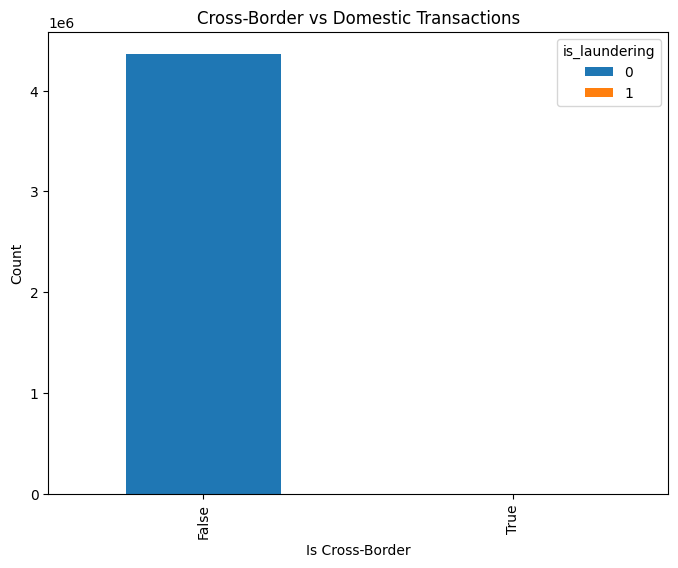

In [7]:
plt.figure(figsize=(8, 6))
cb_counts = df.groupby(['is_cross_border', 'is_laundering']).size().unstack(fill_value=0)
cb_counts.plot(kind='bar', stacked=True, ax=plt.gca())

plt.title("Cross-Border vs Domestic Transactions")
plt.xlabel("Is Cross-Border")
plt.ylabel("Count")
plt.savefig('../data/reports/eda_crossborder.png')
plt.show()

**Key Insight:**
Only 2,191 cross-border transactions (0.05%). Currency used as country proxy in IBM dataset - limited signal for cross-border heuristic.

## SECTION 8: Currency Distribution

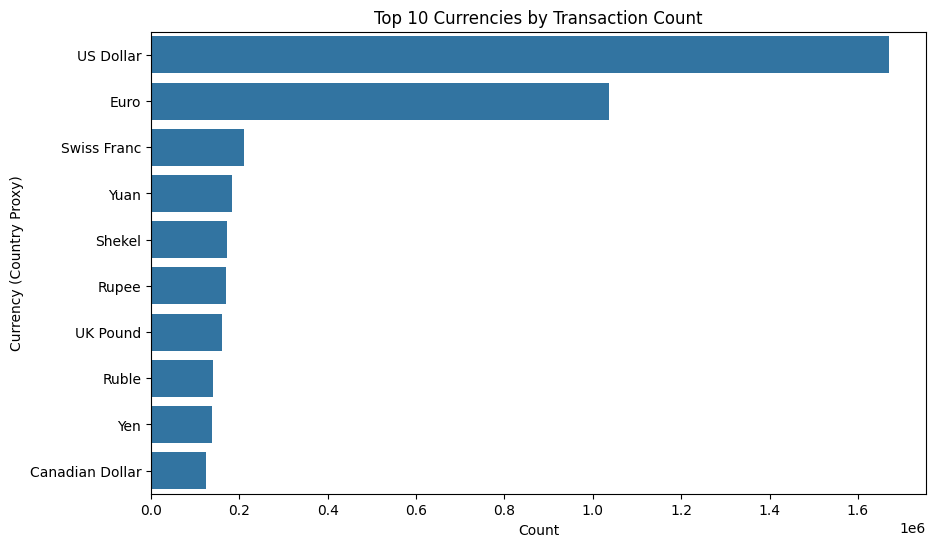

In [8]:
plt.figure(figsize=(10, 6))
top_currencies = df['sender_country'].value_counts().head(10)
sns.barplot(y=top_currencies.index, x=top_currencies.values, orient='h')

plt.title("Top 10 Currencies by Transaction Count")
plt.xlabel("Count")
plt.ylabel("Currency (Country Proxy)")
plt.savefig('../data/reports/eda_currencies.png')
plt.show()

## Key Findings from EDA

1. **Extreme class imbalance** (99.88% clean) makes supervised learning without SMOTE ineffective
2. **Laundering amounts cluster at mid-range** ($3k-$160k) - launderers avoid large amounts to stay below reporting thresholds
3. **No temporal signal** - laundering distributed uniformly across all hours, invalidating time-based heuristics alone
4. **Minimal cross-border activity** (0.05%) - currency proxy is insufficient, graph-based country analysis needed in Phase 2
5. **ACH dominates** (84.9% of transactions) with highest absolute laundering count

These findings directly motivate the hybrid detection approach and graph-based investigation in Phase 2.